# 02 · Regional analysis: where is the shift fastest or slowest, and why?

**Business question:** How fast is Sweden shifting to battery-electric cars among private buyers, where is it fastest or slowest and why, and what BEV share is plausible by 2028?

This notebook covers **where and why**. It compares Sweden's 21 counties (län) on the private BEV share, looks at how each county moved through the bonus surge, the post-bonus fall and the 2026 restart, and tests which county characteristics go with higher shares.

Notebook 01 established the national pattern: private BEV share rose from 21% (2021) to 39% (2022), fell to about 32% in 2024–25, and is 38.6% in Jan–Aug 2026.

## 1. Setup and data

**Choices made here**
- **Private buyers only** (see `CLAUDE.md`). Company and leasing cars are registered in the lessor's county: Stockholm has **about half of all company registrations but under a quarter of private ones** (printed below). Dealer registrations are demo cars. Neither shows where households buy.
- **Periods:** full calendar years 2021–2025, plus **Jan–Aug 2025 and Jan–Aug 2026**, so that 2026 is compared with the same months a year earlier (the seasonality shown in 01).
- **County `99` (Unknown)** is excluded. It has essentially no private registrations (company and dealer cars only).
- **Ratios of sums** throughout: county-period share = BEV registrations ÷ all registrations in that county and period.
- Private-buyer data starts in 2021, so this notebook can't go further back. The 2010–2020 county series covers all owners and would mix in the leasing distortion.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import viz
from viz import BLUE, ORANGE, AQUA, RED, INK, INK2, MUTED, AXIS, GREY_DARK, GREY_LIGHT, SURFACE, PCT
viz.apply_style()
PROC, FIGS = ROOT / "data" / "processed", ROOT / "docs" / "figures"

fact = pd.read_csv(PROC / "fact_registrations_county_monthly.csv", parse_dates=["month"], dtype={"county_code": str})
panel = pd.read_csv(PROC / "county_year_panel.csv", dtype={"county_code": str})

priv = fact[(fact.owner_type == "private") & (fact.county_code != "99")].copy()
LAST = priv.month.max()
priv["year"] = priv.month.dt.year
comp = fact[fact.owner_type == "company"]
print(f"Stockholm's share of company registrations: {comp[comp.county_code == '01'].registrations.sum() / comp.registrations.sum():.1%}"
      f" vs private: {priv[priv.county_code == '01'].registrations.sum() / priv.registrations.sum():.1%}")
print(f"Unknown-county share of private registrations: "
      f"{fact[(fact.owner_type == 'private') & (fact.county_code == '99')].registrations.sum() / fact[fact.owner_type == 'private'].registrations.sum():.3%}")

def county_period(df):
    t = df.pivot_table(index=["county_name", "year"], columns="fuel_type", values="registrations",
                       aggfunc="sum", fill_value=0)
    t["total"] = t.sum(axis=1)
    return t

cy = county_period(priv[priv.year < LAST.year])                     # full years 2021-2025
ytd = county_period(priv[priv.month.dt.month <= LAST.month])        # Jan-Aug every year
YTD_PREV, YTD_CUR = f"Jan–{LAST:%b} {LAST.year - 1}", f"Jan–{LAST:%b} {LAST.year}"

def shares(fuel):
    s = (cy[fuel] / cy.total).unstack()
    s.columns = s.columns.astype(str)
    y = (ytd[fuel] / ytd.total).unstack()
    s[YTD_PREV], s[YTD_CUR] = y[LAST.year - 1], y[LAST.year]
    return s

bev, phev = shares("BEV"), shares("PHEV")
vol = cy.total.unstack()
print(f"{bev.shape[0]} counties; private registrations in 2025 range from "
      f"{vol[2025].min():,.0f} ({vol[2025].idxmin()}) to {vol[2025].max():,.0f} ({vol[2025].idxmax()})")

Stockholm's share of company registrations: 50.8% vs private: 23.1%
Unknown-county share of private registrations: 0.000%
21 counties; private registrations in 2025 range from 356 (Gotland) to 23,211 (Stockholm)


## 2. Where is the private BEV share highest and lowest?

The heatmap shows every county and period and works as the table view for the rest of the notebook. Rows are sorted by 2025, the latest full year.

**Choice: an uncertainty band for the ranking.** A county with 356 private registrations a year (Gotland) can move several points by chance. The dot chart gives each county's 2025 share a 95% Wilson interval. It treats each year's buyers as a sample of the county's underlying tendency to buy a BEV. Where intervals overlap, the ranking between those counties isn't meaningful.

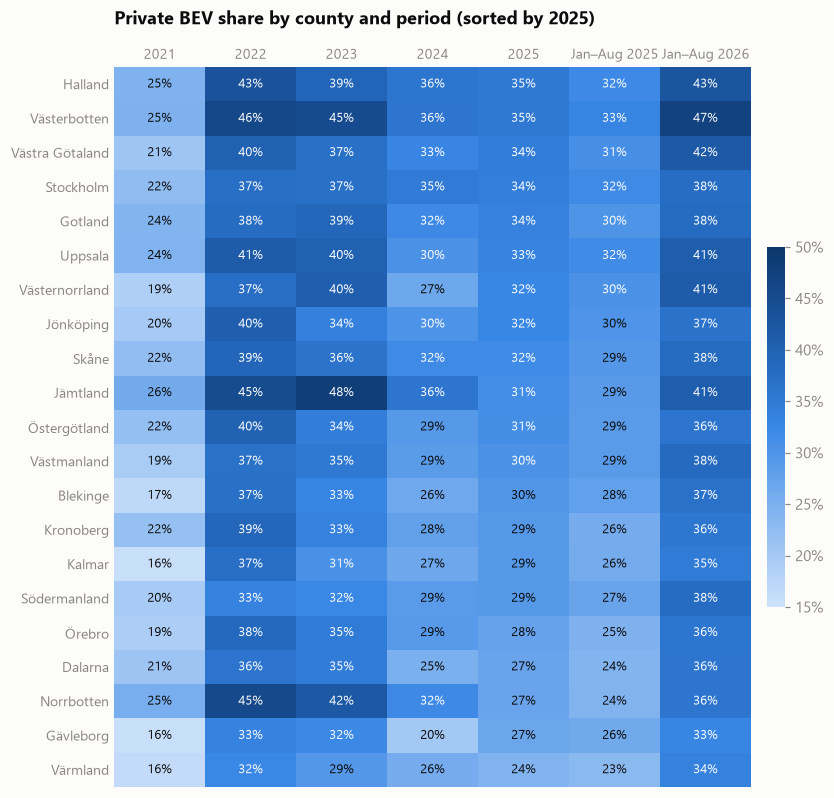

In [2]:
order = bev.sort_values("2025", ascending=False).index
H = bev.loc[order]

fig, ax = plt.subplots(figsize=(9, 8.5))
im = ax.imshow(H.values, cmap=viz.blue_cmap(), vmin=0.15, vmax=0.50, aspect="auto")
ax.set_xticks(range(H.shape[1]), H.columns, rotation=0, fontsize=9)
ax.set_yticks(range(H.shape[0]), H.index, fontsize=9)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False, length=0)
ax.tick_params(axis="y", length=0)
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.iat[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5, color="white" if v > 0.30 else INK)
ax.set_title("Private BEV share by county and period (sorted by 2025)", pad=28)
save_cb = fig.colorbar(im, ax=ax, format=PCT, shrink=0.5, pad=0.02)
save_cb.outline.set_visible(False)
viz.save(fig, "02_county_heatmap", FIGS)
plt.show()

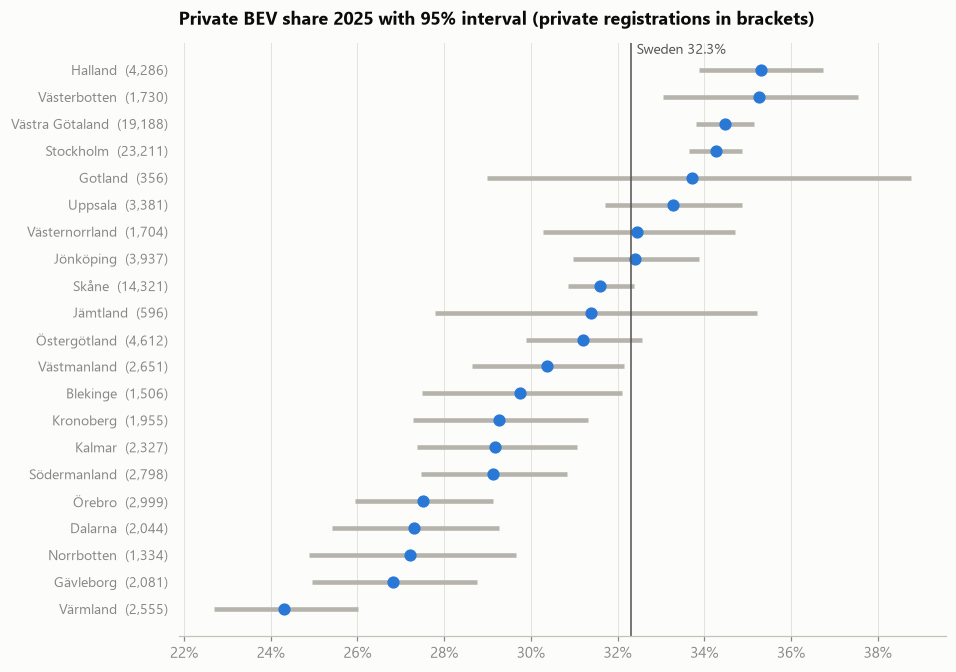

In [3]:
def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centre - half, centre + half

y25 = cy.xs(2025, level="year")
lo, hi = wilson(y25.BEV, y25.total)
d = pd.DataFrame({"share": y25.BEV / y25.total, "lo": lo, "hi": hi, "n": y25.total}).sort_values("share")
nat25 = y25.BEV.sum() / y25.total.sum()

fig, ax = plt.subplots(figsize=(9, 7))
yy = np.arange(len(d))
ax.hlines(yy, d.lo, d.hi, color=GREY_LIGHT, lw=3)
ax.plot(d.share, yy, "o", color=BLUE, ms=7)
ax.axvline(nat25, color=INK2, lw=1)
ax.annotate(f"Sweden {nat25:.1%}", (nat25, len(d) - 0.4), xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_yticks(yy, [f"{c}  ({n:,.0f})" for c, n in zip(d.index, d.n)], fontsize=9)
ax.xaxis.set_major_formatter(PCT)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_title("Private BEV share 2025 with 95% interval (private registrations in brackets)")
viz.save(fig, "02_county_ranking_2025", FIGS)
plt.show()

**What this shows**
- **Highest in 2025:** Halland and Västerbotten (35.3%), Västra Götaland (34.5%) and Stockholm (34.3%). **Lowest:** Värmland (24.3%), Gävleborg (26.8%), Norrbotten (27.2%) and Dalarna (27.3%). In Jan–Aug 2026 Västerbotten (47%) leads clearly, Stockholm has slipped to mid-table (38%), and Gävleborg and Värmland are still lowest (33–34%).
- **The 2025 spread is only about 11 pp from top to bottom.** Most of the middle counties have overlapping intervals, so their rank order is mostly noise. Only the ends of the ranking are clearly separated.
- **The leaders aren't simply the big-city counties.** Stockholm is 4th, Skåne (Malmö) is mid-table, and sparsely populated Västerbotten is joint first. The heatmap also shows that the far north (Norrbotten, Jämtland, Västerbotten) **led in 2021–22**, before Norrbotten and Jämtland fell well down the ranking.

## 3. Do counties move together?

Before explaining differences between counties, it's worth checking their size against the national swings. **Choice:** the same rolling 12-month (R12) share as 01, per county. All 21 counties are drawn in grey, and three are highlighted: **Stockholm** (largest, most urban), **Norrbotten** (the biggest reversal) and **Värmland** (lowest in 2025). The private-buyer R12 for Sweden as a whole is drawn in black.

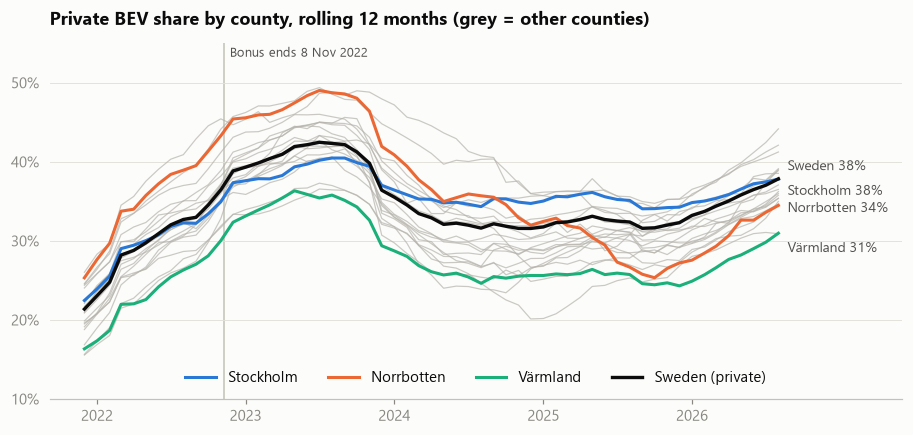

,Sweden (private),county min,county max,range (pp),std across counties (pp)
2021,21.4%,15.6%,26.0%,10.5,3.2
2022,38.8%,32.4%,45.7%,13.4,3.7
2023,36.4%,29.4%,48.0%,18.6,4.7
2024,31.6%,20.1%,36.0%,15.9,4.1
2025,32.3%,24.3%,35.3%,11.0,3.1


In [4]:
m = priv.pivot_table(index="month", columns=["county_name", "fuel_type"], values="registrations",
                     aggfunc="sum", fill_value=0)
cty_bev = m.xs("BEV", axis=1, level="fuel_type")
cty_tot = m.T.groupby(level="county_name").sum().T
r12 = (cty_bev.rolling(12).sum() / cty_tot.rolling(12).sum()).dropna()
r12_nat = (cty_bev.sum(axis=1).rolling(12).sum() / cty_tot.sum(axis=1).rolling(12).sum()).dropna()

HIGHLIGHT = {"Stockholm": BLUE, "Norrbotten": ORANGE, "Värmland": AQUA}
fig, ax = plt.subplots()
for c in r12.columns.difference(list(HIGHLIGHT)):
    ax.plot(r12.index, r12[c], color=GREY_LIGHT, lw=0.8, alpha=0.7)
for c, color in HIGHLIGHT.items():
    ax.plot(r12.index, r12[c], color=color, lw=2, label=c)
ax.plot(r12_nat.index, r12_nat, color=INK, lw=2.2, label="Sweden (private)")
dys = {"Stockholm": -8, "Norrbotten": -2, "Värmland": -10}
for c in HIGHLIGHT:
    viz.label_end(ax, r12[c], f"{c} {r12[c].iloc[-1]:.0%}", dy=dys[c])
viz.label_end(ax, r12_nat, f"Sweden {r12_nat.iloc[-1]:.0%}", dy=8)
viz.mark_bonus(ax, y=0.99)
ax.yaxis.set_major_formatter(PCT)
ax.set_ylim(0.1, 0.55)
ax.set_xlim(right=LAST + pd.DateOffset(months=10))
ax.set_xticks(pd.date_range("2022-01-01", f"{LAST.year}-01-01", freq="YS"))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
ax.set_title("Private BEV share by county, rolling 12 months (grey = other counties)")
ax.legend(loc="lower center", ncol=4)
viz.save(fig, "02_county_r12", FIGS)
plt.show()

spread = pd.DataFrame({"Sweden (private)": [cy.xs(y, level="year").BEV.sum() / cy.xs(y, level="year").total.sum()
                                            for y in range(2021, LAST.year)]}, index=[str(y) for y in range(2021, LAST.year)])
spread["county min"] = bev[spread.index].min()
spread["county max"] = bev[spread.index].max()
spread["range (pp)"] = (spread["county max"] - spread["county min"]) * 100
spread["std across counties (pp)"] = bev[spread.index].std() * 100
spread.style.format({"Sweden (private)": "{:.1%}", "county min": "{:.1%}", "county max": "{:.1%}",
                     "range (pp)": "{:.1f}", "std across counties (pp)": "{:.1f}"})

**What this shows**
- **Counties move together.** Every county surged in 2022, peaked in 2023 and fell in 2024. The standard deviation across counties is only **3–5 pp** in every year, while the national share moved **17 pp** in a single year (2021→2022). The timing of national policy explains far more than location.
- **County differences widened during the shocks:** the standard deviation peaked at **4.7 pp in 2023** and fell back to **3.1 pp in 2025**. Counties reacted to the bonus and its removal with different strength (section 4).
- **Norrbotten went from top to bottom.** It was among the highest counties through the bonus period (R12 peaked near 49% in mid-2023) and fell to about 25% by late 2025, near the bottom. Stockholm moved the least: it gained less in the surge and lost less afterwards.

## 4. How fast did each county move?

Three phases, each measured in percentage points (pp) of private BEV share:
1. **Bonus surge:** 2022 − 2021.
2. **Post-bonus fall:** 2024 − 2022 (bonus peak to trough).
3. **Restart:** Jan–Aug 2026 − Jan–Aug 2025 (same months, so seasonality cancels out).

**Net change** = 2025 − 2021, the full-year change over the whole period. The table is coloured blue for gains and red for falls, with neutral grey around zero.

In [5]:
RESTART = f"restart {(LAST.year - 1) % 100}→{LAST.year % 100} (Jan–{LAST:%b})"
chg = pd.DataFrame({
    "bonus surge 21→22": (bev["2022"] - bev["2021"]) * 100,
    "post-bonus fall 22→24": (bev["2024"] - bev["2022"]) * 100,
    RESTART: (bev[YTD_CUR] - bev[YTD_PREV]) * 100,
    "net 21→25": (bev["2025"] - bev["2021"]) * 100,
}).sort_values(RESTART, ascending=False)
nat = {c: v for c, v in zip(chg.columns, [
    (spread.loc["2022", "Sweden (private)"] - spread.loc["2021", "Sweden (private)"]) * 100,
    (spread.loc["2024", "Sweden (private)"] - spread.loc["2022", "Sweden (private)"]) * 100,
    (ytd.xs(LAST.year, level="year").BEV.sum() / ytd.xs(LAST.year, level="year").total.sum()
     - ytd.xs(LAST.year - 1, level="year").BEV.sum() / ytd.xs(LAST.year - 1, level="year").total.sum()) * 100,
    (spread.loc["2025", "Sweden (private)"] - spread.loc["2021", "Sweden (private)"]) * 100])}
chg.loc["Sweden (private)"] = nat

div = mpl.colors.LinearSegmentedColormap.from_list("div", [RED, "#f0efec", BLUE])
chg.style.format("{:+.1f}").background_gradient(cmap=div, vmin=-16, vmax=16) \
   .set_caption("Change in private BEV share by phase, percentage points (sorted by restart)")

,bonus surge 21→22,post-bonus fall 22→24,restart 25→26 (Jan–Aug),net 21→25
county_name,,,,
Västerbotten,+21.1,-9.7,+14.2,+10.7
Dalarna,+15.2,-11.3,+12.0,+6.3
Jämtland,+18.7,-8.7,+11.7,+5.3
Norrbotten,+20.1,-13.4,+11.7,+1.9
Örebro,+19.3,-9.5,+11.3,+8.4
Västra Götaland,+19.2,-7.4,+10.9,+13.6
Västernorrland,+18.6,-10.7,+10.8,+13.7
Halland,+18.6,-7.5,+10.8,+10.8
Södermanland,+13.7,-4.4,+10.7,+9.5


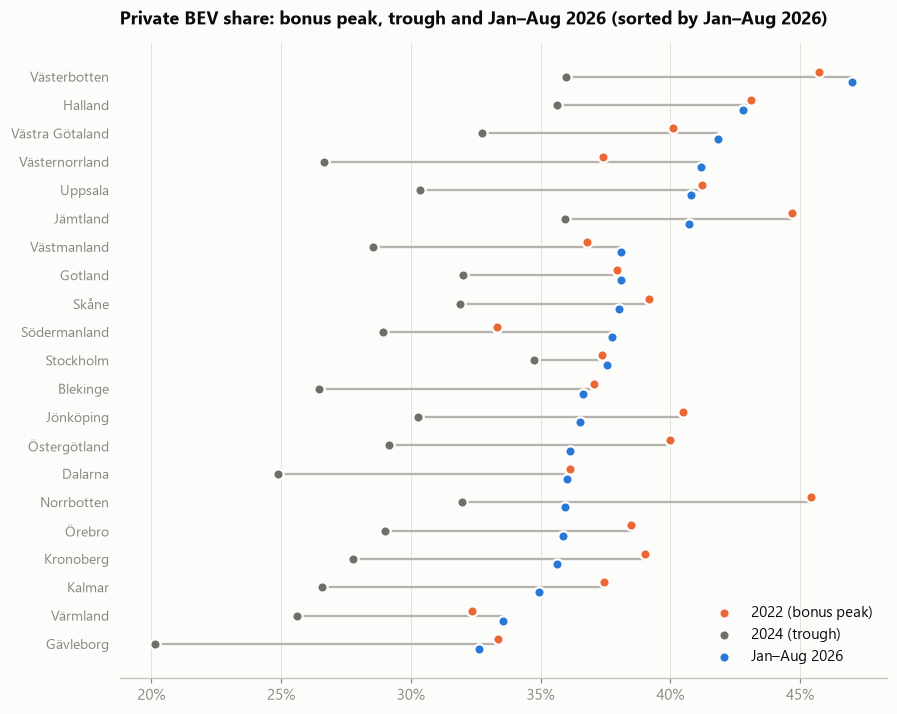

In [6]:
pts = pd.DataFrame({"2022 (bonus peak)": bev["2022"], "2024 (trough)": bev["2024"], YTD_CUR: bev[YTD_CUR]}) \
        .sort_values(YTD_CUR)
fig, ax = plt.subplots(figsize=(9, 7.5))
yy = np.arange(len(pts))
ax.hlines(yy, pts.min(axis=1), pts.max(axis=1), color=GREY_LIGHT, lw=1.5, zorder=1)
for col, color, off in zip(pts.columns, [ORANGE, GREY_DARK, BLUE], [0.18, 0, -0.18]):  # offset so equal values stay visible
    ax.scatter(pts[col], yy + off, s=46, color=color, label=col, zorder=3, edgecolor=SURFACE, linewidth=1.5)
ax.set_yticks(yy, pts.index, fontsize=9)
ax.xaxis.set_major_formatter(PCT)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title(f"Private BEV share: bonus peak, trough and {YTD_CUR} (sorted by {YTD_CUR})")
viz.save(fig, "02_county_phases", FIGS)
plt.show()

**What this shows**
- **Every county fell after the bonus, but by very different amounts.** Stockholm lost only **−2.6 pp** (2022→24) and Södermanland −4.4 pp. Norrbotten (**−13.4 pp**), Gävleborg (−13.2 pp), Dalarna and Kronoberg (about −11 pp) lost the most.
- **The 2026 restart is broad:** every county is up, from +5.7 pp (Stockholm) to +14.2 pp (Västerbotten). Stockholm, which fell least, is now recovering least.
- **Net 2021→2025:** Norrbotten (+1.9 pp) and Jämtland (+5.3 pp) barely moved, having started high in 2021. Counties that started low, such as Kalmar, Västernorrland and Västra Götaland (all about +13.6 pp), gained the most. The ranking has partly **converged**, and the northern lead in 2021 has disappeared.
- The pattern suggests sparsely populated counties are **more sensitive to the purchase price**: bigger gains with the bonus, bigger losses without it, and a bigger rebound now. Section 5 tests this.

## 5. What goes with a higher share, and with faster change?

**Variables available for all 21 counties:**
- **Median earned income** (SCB, age 20–64, thousand SEK), taken from the **previous year** (t−1). 2025 income isn't published yet, and car purchases respond to past income. Logged, so effects read as percentage differences.
- **Population density** (people per km²), logged. Stockholm (380/km²) and Norrbotten (2.5/km²) are 150× apart.
- **Norrland** dummy (Gävleborg, Västernorrland, Jämtland, Västerbotten, Norrbotten). A crude proxy for cold climate and long distances.

**Not available:** charging infrastructure, housing type (villa vs apartment, which determines home charging), commuting distance and fuel prices. These are probably important. Their absence is the biggest limitation here (see `SOURCES.md`).

**Choices**
- **Three outcomes**, not one: BEV share, PHEV share and plug-in share (BEV + PHEV). The geographic question is partly *whether* people buy a plug-in and partly *which kind*.
- Scatter plots first (2025), then a **panel regression** on 21 counties × 5 years (n = 105) with **year fixed effects**. These absorb everything that hit all counties at once (the bonus, prices, model launches), so the coefficients come only from differences *between counties*. Standard errors are **clustered by county**. With only 21 clusters, p-values are approximate.
- **Unweighted** as the main specification, because the question is about counties as places. A version weighted by private registrations is shown as a robustness check, since big counties have less noisy shares.
- This is **descriptive, not causal**: 21 counties, aggregated data and missing variables. County correlations don't describe individual households (ecological inference).

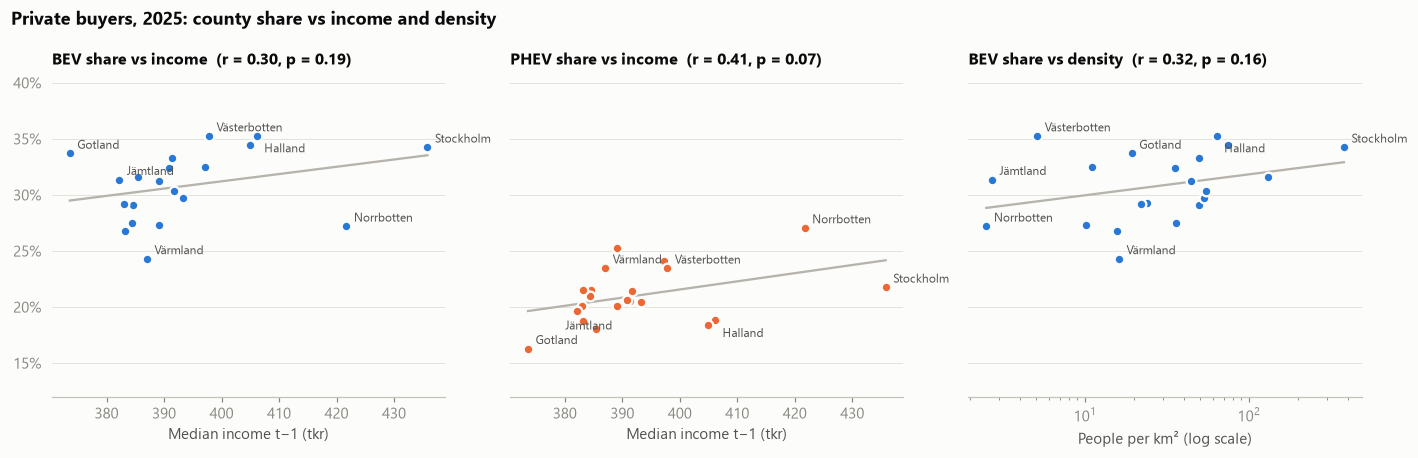

In [7]:
p = panel.sort_values(["county_code", "year"]).copy()
p["inc_lag"] = p.groupby("county_code").median_income_tkr.shift(1)
p = p[p.year.between(2021, LAST.year - 1)].copy()
p["ln_inc"], p["ln_dens"] = np.log(p.inc_lag), np.log(p.pop_per_km2)
p["norrland"] = p.county_code.isin(["21", "22", "23", "24", "25"]).astype(int)
p["plugin_share"] = p.private_bev_share + p.private_phev_share
assert p[["ln_inc", "private_bev_share"]].notna().all().all() and len(p) == 105

c25 = p[p.year == LAST.year - 1].set_index("county_name")
LABEL = ["Stockholm", "Norrbotten", "Värmland", "Halland", "Västerbotten", "Gotland", "Jämtland"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
panels = [("inc_lag", "private_bev_share", "BEV share vs income", "Median income t−1 (tkr)", BLUE),
          ("inc_lag", "private_phev_share", "PHEV share vs income", "Median income t−1 (tkr)", ORANGE),
          ("pop_per_km2", "private_bev_share", "BEV share vs density", "People per km² (log scale)", BLUE)]
for ax, (x, y, title, xl, color) in zip(axes, panels):
    ax.scatter(c25[x], c25[y], s=40, color=color, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    xs = np.log(c25[x]) if x == "pop_per_km2" else c25[x]
    r, pv = stats.pearsonr(xs, c25[y])
    b = np.polyfit(xs, c25[y], 1)
    grid = np.linspace(xs.min(), xs.max(), 50)
    ax.plot(np.exp(grid) if x == "pop_per_km2" else grid, np.polyval(b, grid), color=GREY_LIGHT, lw=1.5, zorder=2)
    nudge = {"Halland": (5, -11)} if y == "private_bev_share" else {"Jämtland": (-8, -12), "Halland": (5, -11)}
    for name in LABEL:
        ax.annotate(name, (c25.loc[name, x], c25.loc[name, y]), xytext=nudge.get(name, (5, 3)),
                    textcoords="offset points", fontsize=8, color=INK2)
    if x == "pop_per_km2":
        ax.set_xscale("log")
    ax.set_title(f"{title}  (r = {r:.2f}, p = {pv:.2f})", fontsize=10.5)
    ax.set_xlabel(xl)
    ax.yaxis.set_major_formatter(PCT)
axes[0].set_ylim(0.12, 0.40)
fig.suptitle("Private buyers, 2025: county share vs income and density", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
fig.tight_layout()
viz.save(fig, "02_correlates_2025", FIGS)
plt.show()

In [8]:
def fit(y, rhs="ln_inc + ln_dens", weighted=False):
    f = f"{y} ~ {rhs} + C(year)"
    mod = smf.wls(f, p, weights=p.private_new_regs) if weighted else smf.ols(f, p)
    return mod.fit(cov_type="cluster", cov_kwds={"groups": p.county_code})

# Rescale coefficients into readable units
SCALE = {"ln_inc": np.log(1.10) * 100, "ln_dens": np.log(2) * 100, "norrland": 100}
LABELS = {"ln_inc": "+10% income (pp)", "ln_dens": "2× density (pp)", "norrland": "Norrland (pp)"}

specs = {}
for y, yname in [("private_bev_share", "BEV"), ("private_phev_share", "PHEV"), ("plugin_share", "Plug-in")]:
    specs[(yname, "main")] = fit(y)
    specs[(yname, "weighted")] = fit(y, weighted=True)
    specs[(yname, "+Norrland")] = fit(y, "ln_inc + ln_dens + norrland")

rows = {}
for key, res in specs.items():
    col = {}
    for v in SCALE:
        if v in res.params:
            b, se, pv = res.params[v] * SCALE[v], res.bse[v] * SCALE[v], res.pvalues[v]
            stars = "***" if pv < 0.01 else "**" if pv < 0.05 else "*" if pv < 0.1 else ""
            col[LABELS[v]] = f"{b:+.1f}{stars} ({se:.1f})"
        else:
            col[LABELS[v]] = ""
    col["R² (incl. year FE)"] = f"{res.rsquared:.2f}"
    col["R² year FE only (unweighted)"] = f"{smf.ols(res.model.endog_names + ' ~ C(year)', p).fit().rsquared:.2f}"
    rows[key] = col
reg = pd.DataFrame(rows)
reg.columns = pd.MultiIndex.from_tuples(reg.columns)
reg.style.set_caption("County panel 2021–2025, year fixed effects, county-clustered SE in brackets. "
                      "* p<0.1, ** p<0.05, *** p<0.01")

**Reading the regression.** Coefficients are percentage points of share. For example, "+10% income" is the predicted difference between two counties whose median income differs by 10%, holding density and year fixed.

- **Income goes with plug-ins as a whole.** A 10% higher median income goes with a plug-in share about **5.5 pp higher** (main +5.6, weighted +5.3, both p < 0.01). It's split roughly evenly between BEV (+3.5 pp main, +2.2 weighted) and PHEV (+2.1 main, +3.1 weighted). Adding the Norrland dummy inflates the standard errors, but the plug-in effect stays (+4.7, p < 0.1).
- **Density has little independent effect on the level** once income is controlled for: at most −0.9 pp of plug-in share per doubling, and only in one specification. The simple density correlation in the scatter plot runs mostly through Stockholm's income.
- **Norrland adds nothing measurable.** It's too collinear with density (r ≈ −0.7) to separate them with 21 counties.
- **Norrbotten** is the clearest exception: its income is the second highest (mining wages), but it has the highest PHEV share (27%) and a low BEV share. Distances and cold climate may favour PHEVs there, but that's a hypothesis the data can't test.

**Timing matters far more than location.** Year fixed effects alone explain **74%** of the variation in county BEV share. Income and density add about **3 points** (R² 0.74 → 0.77).

### Why did some counties fall harder after the bonus?

Section 4 suggested that sparsely populated counties reacted more strongly. Two tests:
1. A **cross-section** (21 counties) of each phase's change against log density and log income (2022 income for the fall, 2024 income for the restart), with robust (HC3) standard errors.
2. The panel model with **density, income and Norrland interacted with a post-bonus dummy** (2023+). This asks whether the gradient changed once the bonus was gone.

,post-bonus fall (pp),2026 restart (pp),panel: density × post (pp)
effect of 2× density,+0.90,-0.75,+0.94
p-value,+0.04,+0.01,+0.03


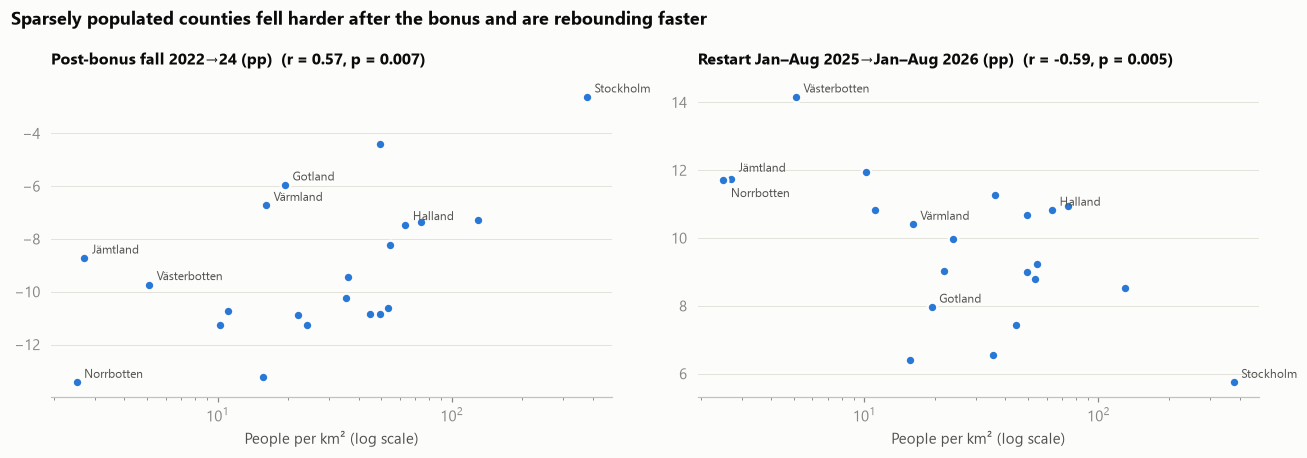

In [9]:
inc = p.pivot(index="county_name", columns="year", values="ln_inc")
dens = p.pivot(index="county_name", columns="year", values="ln_dens")
x = pd.DataFrame({"fall": chg["post-bonus fall 22→24"], "restart": chg[RESTART],
                  "ln_dens": dens[2024], "ln_inc22": inc[2022], "ln_inc24": inc[2024]}).drop("Sweden (private)")

res_fall = smf.ols("fall ~ ln_dens + ln_inc22", x).fit(cov_type="HC3")
res_rest = smf.ols("restart ~ ln_dens + ln_inc24", x).fit(cov_type="HC3")
p["post"] = (p.year >= 2023).astype(int)
# post itself is absorbed by the year fixed effects, so only the interactions enter
res_int = smf.ols("private_bev_share ~ ln_inc + ln_dens + norrland + ln_inc:post + ln_dens:post + norrland:post"
                  " + C(year)", p) \
             .fit(cov_type="cluster", cov_kwds={"groups": p.county_code})

out = pd.DataFrame({
    "post-bonus fall (pp)": [res_fall.params["ln_dens"] * np.log(2), res_fall.pvalues["ln_dens"]],
    "2026 restart (pp)": [res_rest.params["ln_dens"] * np.log(2), res_rest.pvalues["ln_dens"]],
    "panel: density × post (pp)": [res_int.params["ln_dens:post"] * np.log(2) * 100, res_int.pvalues["ln_dens:post"]],
}, index=["effect of 2× density", "p-value"])
display(out.style.format("{:+.2f}").set_caption("Does density change how strongly counties react?"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, col, title in [(axes[0], "fall", "Post-bonus fall 2022→24 (pp)"),
                       (axes[1], "restart", f"Restart {YTD_PREV}→{YTD_CUR} (pp)")]:
    ax.scatter(np.exp(x.ln_dens), x[col], s=40, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    r, pv = stats.pearsonr(x.ln_dens, x[col])
    nudge = {"Norrbotten": (5, -11), "Jämtland": (5, 5)} if col == "restart" else {}
    for name in LABEL:
        ax.annotate(name, (np.exp(x.loc[name, "ln_dens"]), x.loc[name, col]), xytext=nudge.get(name, (5, 3)),
                    textcoords="offset points", fontsize=8, color=INK2)
    ax.set_xscale("log")
    ax.set_xlabel("People per km² (log scale)")
    ax.set_title(f"{title}  (r = {r:.2f}, p = {pv:.3f})", fontsize=10.5)
fig.suptitle("Sparsely populated counties fell harder after the bonus and are rebounding faster",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout()
viz.save(fig, "02_density_vs_change", FIGS)
plt.show()

**What this shows**
- **Density is the clearest regional signal in the *changes*, not the levels.** Each halving of population density goes with about **0.9 pp more lost** after the bonus (p = 0.04) and about **0.75 pp more regained** in 2026 (p = 0.01), controlling for income. From Stockholm to Norrbotten (about 7 halvings), that's a difference of 5–6 pp in each phase.
- The panel interaction points the same way: after the bonus, each doubling of density is worth **+0.9 pp** of BEV share relative to before (p = 0.03).
- **One reading:** in sparsely populated counties BEVs were bought largely *because of* the bonus, which made a then-expensive car affordable. When it ended, those buyers went back to PHEVs and combustion cars. The 2026 rebound there is consistent with **falling BEV prices doing what the bonus used to do**. Notebook 03 tests the bonus effect directly, and price data would be needed to confirm the price explanation.
- Stockholm is the mirror image. It was the least price-sensitive throughout, which fits a buyer base with higher incomes and more company-car spillover. It rose least, fell least and is rebounding least.

## 6. Summary: where is it fastest or slowest, and why?

1. **Regional differences are small next to national swings.** Counties differ by 3–5 pp (standard deviation) in any year, while the national private share moved 17 pp in one year and every county followed the same rise, fall and restart. Year effects alone explain 74% of county-year variation. National policy and the market set the pace. Location adjusts it.
2. **Highest (2025):** Halland, Västerbotten, Västra Götaland, Stockholm (34–35%). **Lowest:** Värmland, Gävleborg, Norrbotten, Dalarna (24–27%). Mid-table rankings are within noise. In Jan–Aug 2026 Västerbotten leads (47%).
3. **The early northern lead disappeared.** Norrbotten and Jämtland were at the top in 2021–22, Norrbotten fell the most after the bonus ended (−13 pp), and both have the smallest net gains since 2021.
4. **Income goes with plug-ins in general** (about +5.5 pp plug-in share per +10% income), split roughly evenly between BEV and PHEV. Where income is high but distances are long (Norrbotten), the extra spending goes to PHEVs.
5. **Density shapes how strongly counties react, not where they end up.** Each halving of density is worth about 0.9 pp more lost after the bonus and 0.75 pp more regained in 2026. Stockholm is the most stable: smallest surge, smallest fall, smallest rebound.

**Limitations:** 21 counties; aggregated data (no household-level inference); no charging, housing, commuting or price data; leasing and company cars excluded by design; income is 20–64 earned income only.

**For 03 and 04**
- **03 · Policy:** the bonus effect is likely *heterogeneous*. Estimate the interrupted time series nationally, then for low- vs high-density counties.
- **04 · Forecast:** forecast the national private share. Regional splits are too noisy for a 2028 horizon. The convergence seen here means a national model shouldn't miss large regional divergence.